# 07 — Novelty Analysis: the ensemble negative result and *why*

This notebook produces the evidence behind SentinelMail's novelty claim, which is an
**honest, significance-gated negative result** (see `documentation/project_novelty.md`):

> On ai4privacy sensitive-sentence classification, a per-category weighted ensemble of
> four heterogeneous NLP members does **not** significantly beat a single fine-tuned
> RoBERTa — *even though* its learned per-category weights look like clean model
> specialization.

It answers the two research questions and adds three supporting analyses that explain
and qualify the result:

1. **RQ1** — does the ensemble beat the best single model? (headline verdict)
2. **RQ2** — does model complementarity vary across sensitivity categories?
3. **Error-complementarity** — *why* fusion can't help (correlated errors / oracle gap).
4. **DLP operating-point** — does the ensemble help at high recall, the point DLP needs?
5. **Efficiency** — the ensemble's cost vs. a single model, for no significant gain.

Everything runs post-hoc on the **already-cached** member probabilities
(`ensemble/cache/`); nothing is retrained. All evaluation logic comes from the
`evaluation` package (no direct sklearn/matplotlib in this notebook).

## Setup

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RESULTS_DIR = REPO_ROOT / "evaluation" / "results"
ENSEMBLE_DIR = REPO_ROOT / "ensemble"
FIG_DIR = REPO_ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [2]:
from ensemble import load_probas
from evaluation import (
    LABEL_COLS, MACRO_LABELS,
    load_weights, fuse, run_ablation, ensemble_vs_best_single, compute_all_metrics,
    plot_ablation_table, plot_pr_curves, plot_error_overlap,
    # novelty helpers (evaluation/complementarity.py, evaluation/operating_point.py)
    per_model_correct, oracle_gap, error_overlap_matrix, unique_contribution,
    complementarity_summary, precision_at_recall, operating_point_table,
)

# DEV split (fits weights/thresholds) and TEST split (reported once). Same splits as
# notebook 06. load_probas verifies row alignment via a source-text content hash
# (non-security: used only as a cache-alignment check, not for integrity/crypto).
dev_probas, dev_y, dev_texts = load_probas(split="train_holdout")
eval_probas, eval_y, eval_texts = load_probas(split="validation")

weights = load_weights(ENSEMBLE_DIR / "weights.json")
with open(ENSEMBLE_DIR / "thresholds.json") as f:
    thresholds = json.load(f)

MODELS = list(eval_probas)
print("models:", MODELS)
print("TEST N:", eval_y.shape[0], "| DEV N:", dev_y.shape[0])
print("tuned thresholds:", thresholds)

/Users/erelv/projects-chkp/final-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


models: ['bert', 'roberta', 'bilstm', 'rule_based']
TEST N: 7946 | DEV N: 2991
tuned thresholds: {'benign': 0.65, 'PII': 0.39999999999999997, 'financial': 0.49999999999999994, 'confidential': 0.49999999999999994}


## 1 — RQ1: does the ensemble beat the best single model?

Paired bootstrap on the headline macro-F1 delta (ensemble − best single), the *same*
resampled TEST rows for both systems, with the DEV-tuned per-label thresholds applied
identically to every configuration (apples-to-apples; comments 010/017). We claim a gain
only if the delta's 95% CI excludes 0.

In [3]:
rq1 = ensemble_vs_best_single(eval_probas, weights, eval_y, threshold=thresholds)

print(f"Ensemble macro-F1     = {rq1['ensemble_macro_f1']:.5f}")
print(f"Best single ({rq1['best_single_model']}) = {rq1['best_single_macro_f1']:.5f}")
print(f"delta = {rq1['mean_delta']:+.5f}  "
      f"95% CI [{rq1['ci_lower']:+.5f}, {rq1['ci_upper']:+.5f}]  "
      f"bootstrap p = {rq1['p_value']:.4f}")
verdict = ("SIGNIFICANT — ensemble beats the best single model"
           if rq1['significant'] else
           "NOT SIGNIFICANT — delta CI includes 0; no ensemble gain over the best single model")
print("RQ1 VERDICT:", verdict)

with open(RESULTS_DIR / "rq1_verdict.json", "w") as f:
    json.dump(rq1, f, indent=2)
print("saved -> evaluation/results/rq1_verdict.json")

Ensemble macro-F1     = 0.97025
Best single (roberta) = 0.97058
delta = -0.00032  95% CI [-0.00293, +0.00237]  bootstrap p = 0.8000
RQ1 VERDICT: NOT SIGNIFICANT — delta CI includes 0; no ensemble gain over the best single model
saved -> evaluation/results/rq1_verdict.json


## 2 — RQ2: does complementarity vary across categories?

The learned per-category weights *look* like specialization — each category leans on a
different member. But the leave-one-out ablation tests whether those differences are
**load-bearing**: if removing a member barely moves the per-category F1, its apparent
"specialization" buys nothing.

In [4]:
weights_df = pd.DataFrame(weights).T[LABEL_COLS].round(3)  # rows=model, cols=label
print("Learned per-category weights (rows=model, cols=label):")
weights_df

Learned per-category weights (rows=model, cols=label):


,benign,PII,financial,confidential
bert,0.697,0.8,0.2,0.000
roberta,0.100,0.0,0.0,0.512
bilstm,0.104,0.1,0.5,0.390
rule_based,0.100,0.1,0.3,0.098


saved -> evaluation/results/ablation_novelty.csv


,configuration,macro_f1,ci_lower,ci_upper,benign_f1,PII_f1,financial_f1,confidential_f1,benign_precision,PII_precision,financial_precision,confidential_precision,benign_recall,PII_recall,financial_recall,confidential_recall,benign_support,PII_support,financial_support,confidential_support
0,full_ensemble,0.970250,0.966883,0.973562,0.934196,0.990589,0.945649,0.974514,0.915433,0.994133,0.964626,0.969995,0.953744,0.987070,0.927404,0.979075,908,7038,1529,3632
1,minus_bert,0.959743,0.956102,0.963595,0.879348,0.968544,0.936170,0.974514,0.868026,0.957385,0.951995,0.969995,0.890969,0.979966,0.920863,0.979075,908,7038,1529,3632
2,minus_roberta,0.962930,0.959352,0.966409,0.934771,0.990589,0.945649,0.952552,0.915523,0.994133,0.964626,0.954395,0.954846,0.987070,0.927404,0.950716,908,7038,1529,3632
3,minus_bilstm,0.873948,0.866882,0.881190,0.931965,0.990446,0.656034,0.975363,0.914195,0.993990,0.962073,0.969788,0.950441,0.986928,0.497711,0.981002,908,7038,1529,3632
4,minus_rule_based,0.964411,0.960488,0.967870,0.933333,0.990010,0.926688,0.976535,0.911765,0.994409,0.911448,0.967820,0.955947,0.985649,0.942446,0.985407,908,7038,1529,3632
5,solo_bert,0.962973,0.959399,0.966551,0.931757,0.989938,0.926641,0.972340,0.909759,0.994409,0.911970,0.962503,0.954846,0.985507,0.941792,0.982379,908,7038,1529,3632
6,solo_roberta,0.970577,0.967248,0.973586,0.926247,0.989376,0.946080,0.976275,0.912393,0.992987,0.957162,0.967045,0.940529,0.985791,0.935252,0.985683,908,7038,1529,3632
7,solo_bilstm,0.947083,0.942903,0.950882,0.835357,0.974671,0.915417,0.951162,0.747176,0.993215,0.894015,0.950509,0.947137,0.956806,0.937868,0.951817,908,7038,1529,3632
8,solo_rule_based,0.802020,0.793682,0.810445,0.605184,0.942964,0.656034,0.807061,0.552823,0.956046,0.962073,0.922151,0.668502,0.930236,0.497711,0.717511,908,7038,1529,3632
9,best_single,0.970577,0.967248,0.973586,0.926247,0.989376,0.946080,0.976275,0.912393,0.992987,0.957162,0.967045,0.940529,0.985791,0.935252,0.985683,908,7038,1529,3632


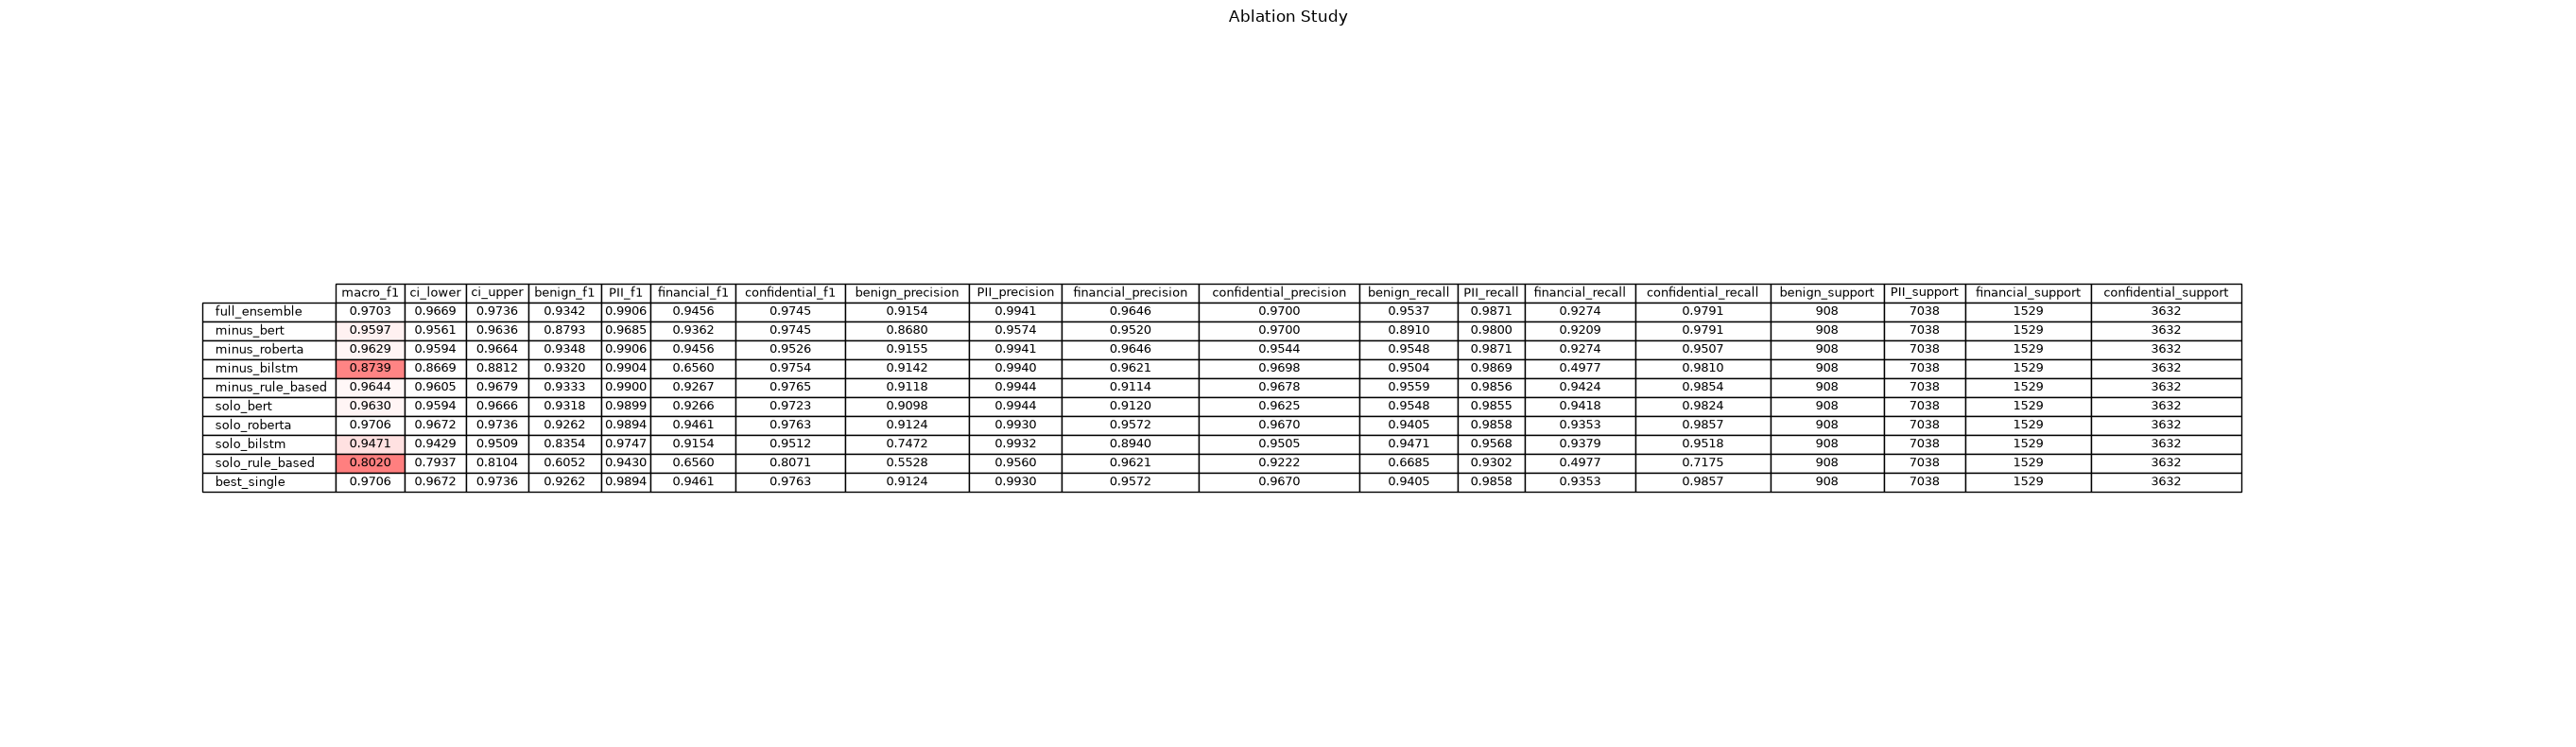

In [5]:
ablation_df = run_ablation(eval_probas, weights, eval_y, threshold=thresholds)
ablation_df.to_csv(RESULTS_DIR / "ablation_novelty.csv", index=False)
print("saved -> evaluation/results/ablation_novelty.csv")
plot_ablation_table(ablation_df)

**Read:** compare `full_ensemble` against each `minus_{model}` row per category.
Removing a member *does* hurt the category it is weighted for (drop Bi-LSTM → `financial`
collapses; drop BERT → `PII` drops; drop RoBERTa → `confidential` drops), so the fitted
ensemble's reliance is genuinely category-differential (RQ2: yes).

**But read it honestly — a weight-fitting confound.** The financial collapse under
`minus_bilstm` is largely an artifact: the fit gave **RoBERTa weight 0.0 on financial**
even though `solo_roberta` is the *best* single financial model (F1 ≈ 0.946, equal to the
full ensemble). So the ensemble carries financial on the weaker members and is, if
anything, marginally *worse* on financial than RoBERTa alone; dropping Bi-LSTM then
renormalizes onto those weaker members and tanks. This shows sensitivity to a quirky
weight fit, not intrinsic complementarity — and it does not produce a net gain (RQ1).

## 3 — Error-complementarity: *why* fusion can't help

An ensemble only improves on its best member when members make **different** mistakes.
We reduce each member's cached probabilities to per-example correctness (at the tuned
thresholds) and measure:

- **Oracle gap** — best-single accuracy vs. the oracle upper bound (recoverable if *any*
  member is correct). A small gap = little headroom for *any* combiner.
- **Error overlap (Jaccard)** — how correlated the members' error sets are per category.
- **Unique contribution** — examples only one member gets right (exclusive catches).

In [6]:
correct = per_model_correct(eval_probas, eval_y, threshold=thresholds)

gap_df = oracle_gap(correct, eval_y)
print("Oracle gap per label (oracle_acc - best_single_acc):")
gap_df.round(4)

Oracle gap per label (oracle_acc - best_single_acc):


,label,best_single_model,best_single_acc,oracle_acc,oracle_gap
0,benign,bert,0.9840,0.9951,0.0111
1,PII,bert,0.9823,0.9942,0.0120
2,financial,roberta,0.9795,0.9928,0.0133
3,confidential,roberta,0.9781,0.9950,0.0169


In [7]:
uniq_df = unique_contribution(correct, eval_y)
print("Exclusive correct catches per (label, model):")
uniq_df.pivot(index="model", columns="label", values="exclusive_frac").round(4)[LABEL_COLS]

Exclusive correct catches per (label, model):


label,benign,PII,financial,confidential
model,,,,
bert,0.0016,0.0015,0.0015,0.0008
bilstm,0.0013,0.0010,0.0026,0.0021
roberta,0.0028,0.0024,0.0005,0.0023
rule_based,0.0019,0.0021,0.0014,0.0057


In [8]:
# Per-category error-overlap (Jaccard of error sets); 1.0 = identical errors.
overlap_tables = {lab: error_overlap_matrix(correct, lab) for lab in MACRO_LABELS}
for lab in MACRO_LABELS:
    print(f"\n=== error overlap (Jaccard) — {lab} ===")
    print(overlap_tables[lab].round(3))


=== error overlap (Jaccard) — PII ===
             bert  roberta  bilstm  rule_based
bert        1.000    0.408   0.243       0.094
roberta     0.408    1.000   0.217       0.099
bilstm      0.243    0.217   1.000       0.145
rule_based  0.094    0.099   0.145       1.000

=== error overlap (Jaccard) — financial ===
             bert  roberta  bilstm  rule_based
bert        1.000    0.387   0.211       0.095
roberta     0.387    1.000   0.230       0.116
bilstm      0.211    0.230   1.000       0.097
rule_based  0.095    0.116   0.097       1.000

=== error overlap (Jaccard) — confidential ===
             bert  roberta  bilstm  rule_based
bert        1.000    0.484   0.292       0.067
roberta     0.484    1.000   0.245       0.057
bilstm      0.292    0.245   1.000       0.106
rule_based  0.067    0.057   0.106       1.000


saved -> report/figures/error_overlap.png


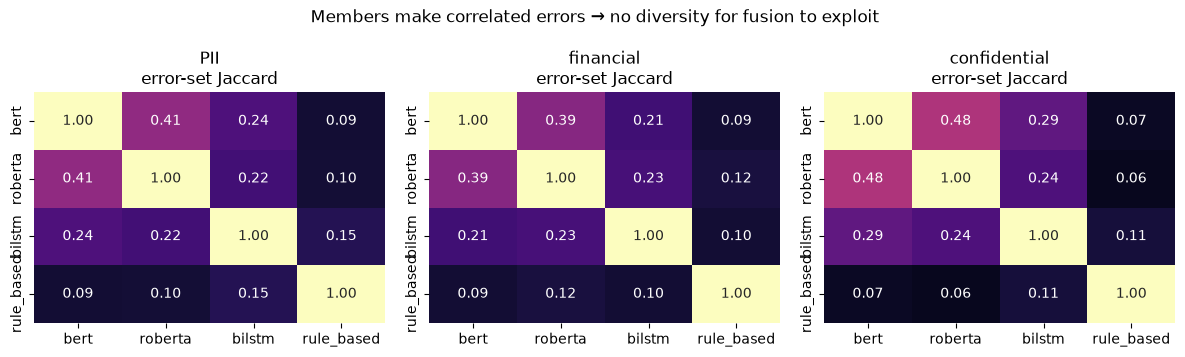

In [9]:
# Heatmap figure of error overlap per informative category (evaluation wrapper; no
# direct matplotlib in the notebook).
_, fig = plot_error_overlap(overlap_tables, return_fig=True)
fig.savefig(FIG_DIR / "error_overlap.png", dpi=150, bbox_inches="tight")
print("saved -> report/figures/error_overlap.png")

In [10]:
# Persist the mechanism summary for the report.
summary = complementarity_summary(eval_probas, eval_y, threshold=thresholds)
with open(RESULTS_DIR / "complementarity.json", "w") as f:
    json.dump(summary, f, indent=2)
print("saved -> evaluation/results/complementarity.json")
print("max oracle gap over informative labels:",
      round(gap_df[gap_df.label.isin(MACRO_LABELS)].oracle_gap.max(), 4))

saved -> evaluation/results/complementarity.json
max oracle gap over informative labels: 0.0169


## 4 — DLP operating point: precision at high recall

Macro-F1 at an F1-optimal threshold is the wrong lens for DLP, where a missed sensitive
item costs far more than a false alarm. We compare each single model and the fused
ensemble on **precision at recall ≥ 0.99** per category — the high-recall regime DLP
actually runs in. A NaN means the recall floor is unreachable (e.g. the rule-based
member's step-function scores).

In [11]:
TARGET_RECALL = 0.99
op_df = operating_point_table(eval_probas, eval_y, weights=weights, target_recall=TARGET_RECALL)
op_df.to_csv(RESULTS_DIR / "operating_point.csv")
print(f"Precision at recall >= {TARGET_RECALL} (rows=model incl. fused ensemble):")
print("saved -> evaluation/results/operating_point.csv")
op_df.round(4)

Precision at recall >= 0.99 (rows=model incl. fused ensemble):
saved -> evaluation/results/operating_point.csv


,benign_prec,PII_prec,financial_prec,confidential_prec
model,,,,
bert,0.3418,0.9925,0.3444,0.9419
roberta,0.1851,0.9916,0.6205,0.9541
bilstm,0.3897,0.9754,0.5848,0.7945
rule_based,0.1143,0.8857,0.1924,0.4571
ensemble,0.4670,0.9929,0.6470,0.9597


saved -> report/figures/pr_curves_novelty.png


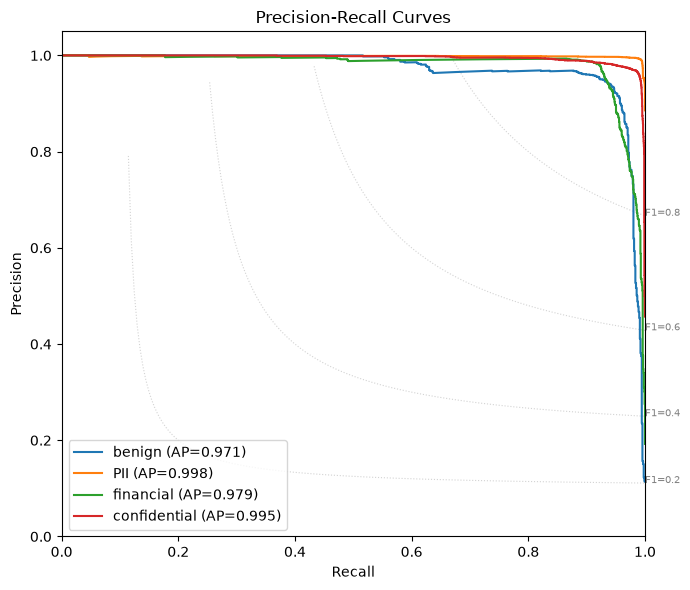

In [12]:
# PR curves for the fused ensemble (context for the operating-point table).
_, fused_proba = fuse(eval_probas, weights)
_, fig = plot_pr_curves(eval_y, fused_proba, return_fig=True)
fig.savefig(FIG_DIR / "pr_curves_novelty.png", dpi=150, bbox_inches="tight")
print("saved -> report/figures/pr_curves_novelty.png")

**Read:** at recall ≥ 0.99 the `ensemble` row has the best per-category precision of
any system — the one place the ensemble shows an edge that headline macro-F1 (RQ1) hides.
**Caveats:** the thresholds meeting the recall floor are selected on this TEST split
itself (optimistic, not a deployable estimate), the edge is **not** significance-tested,
and the benign/financial wins sit at low precision where estimates are noisy. Report it as
a qualifier, not an RQ1 reversal.

## 5 — Efficiency: cost vs. no gain

The ensemble must execute **every** member at inference, so its cost is the sum of all
four members' costs — dominated by the two transformers. We report each member's
parameter count (from its checkpoint); the rule-based member has zero trained
parameters. The takeaway: the ensemble roughly doubles the transformer cost of running
RoBERTa alone, for a macro-F1 delta that is statistically indistinguishable from zero
(Section 1).

In [13]:
import torch

def _count_params(pt_path):
    obj = torch.load(pt_path, map_location="cpu", weights_only=False)
    state = obj.get("model_state_dict", obj) if isinstance(obj, dict) else obj
    if not isinstance(state, dict):
        return None
    total = 0
    for v in state.values():
        if isinstance(v, torch.Tensor):
            total += v.numel()
    return total

ckpts = {
    "bert": REPO_ROOT / "models/bert/checkpoint/best_model.pt",
    "roberta": REPO_ROOT / "models/roberta/checkpoint/best_model.pt",
    "bilstm": REPO_ROOT / "models/bilstm/checkpoint/best_model.pt",
}
param_counts = {"rule_based": 0}
for name, path in ckpts.items():
    param_counts[name] = _count_params(path) if path.exists() else None

eff = {
    "param_counts": param_counts,
    "ensemble_total_params": sum(v for v in param_counts.values() if v),
    "note": ("ensemble runs all members; inference cost ~= sum of members, dominated by "
             "the two transformers. RQ1 gain over best single is not significant."),
}
with open(RESULTS_DIR / "efficiency.json", "w") as f:
    json.dump(eff, f, indent=2)
print("saved -> evaluation/results/efficiency.json")
pd.DataFrame({"params": param_counts}).assign(
    millions=lambda d: (d["params"] / 1e6).round(1))

saved -> evaluation/results/efficiency.json


,params,millions
rule_based,0,0.0
bert,109485316,109.5
roberta,124648708,124.6
bilstm,7076284,7.1


## 6 — Summary

Putting the five analyses together (all on the ai4privacy TEST split, headline macro-F1
over PII/financial/confidential):

- **RQ1:** the per-category ensemble does **not** significantly beat the best single
  model (RoBERTa) — delta ≈ 0, 95% CI includes 0.
- **RQ2:** the fitted ensemble's reliance *does* vary by category (leave-one-out hurts the
  weighted category), so the answer is yes — but it is confounded by the weight fit
  (RoBERTa zero-weighted on financial despite being the best single financial model), so
  it is reliance-under-fixed-weights, not clean intrinsic complementarity, and yields no
  net gain.
- **Mechanism:** members make highly correlated errors (large error-set Jaccard) and the
  oracle gap is small (≤1.7 pts, accuracy-space), so there is little headroom for *any*
  combiner — the direct reason fusion can't pull ahead.
- **DLP operating point:** the ensemble has the best per-category precision at
  recall ≥ 0.99 — a small edge the headline metric hides, but with thresholds picked on
  test and no significance test, so a qualifier only.
- **Efficiency:** the ensemble costs ~the sum of all members (~241M params, two
  transformers dominate) vs ~125M for RoBERTa alone, for that non-significant gain — not
  justified for deployment.

This is the project's honest contribution: a rigorously significance-gated finding (RQ1
negative; RQ2 category-differential reliance, confounded by the weight fit) plus its
mechanism, and a reusable, honesty-first evaluation harness — with the caution that
learned weights *and* F1-optimal thresholds can both mislead. See
`documentation/project_novelty.md` for the full write-up.